# 03 — Insights: what drives the furnace's energy use and how to get 2% below the baseline

This notebook answers four questions, each with numbers and a chart:

| # | Question | Section |
|---|---|---|
| 1 | Which data can we trust, and how much is left after cleaning? | §1 |
| 2 | Do we reproduce the client's baseline (1,576.3 kcal/kg) from raw data? | §2 |
| 3 | What drives SFC: draw, furnace ageing, NCV, barrier boost, air, cullet? | §3 – §8 |
| 4 | How much can each lever save, and is 2% reachable? | §9 – §10 |

**Data:** the analytical record (15-min) and the DCS crown thermocouple (1-min), cleaned by `src/data_prep.py` (notebooks 01–02).

**Client values used:** only the baseline 1,576.3 kcal/kg and target 1,544.8 (the numbers we must beat) and the 5-t draw-band definition. Everything else is recomputed from raw data.

In [1]:
import sys; sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import data_prep as dp
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 1.6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'figure.dpi': 110})
import recommender as rc
d = pd.read_parquet('../data/processed/daily_clean.parquet')
h = pd.read_parquet('../data/processed/hourly_clean.parquet')
q = pd.read_parquet('../data/processed/ar_15min_clean.parquet')
u = d[d.usable].copy()
u['age_m'] = (u.index - pd.Timestamp('2025-09-01')).days / 30.44           # furnace-age proxy (months)
u['E_g'] = u.energy_kcal / 1e6; u['gas_g'] = u.gas_kcal / 1e6
u['bb_g'] = u.bb_kwh * 860 / 1e6; u['mb_g'] = u.mb_kwh * 860 / 1e6
u['mon'] = u.index.to_period('M').astype(str)
base = u[u.in_baseline].copy()
def label_right(ax, x, y, text):
    ax.text(x, y, text, color=INK2, fontsize=9, va='center')

## 1. Which data is used
### 1a. Days available after cleaning
A day is **usable** when:
- the NCV meter worked for at least 90% of the day (your rule: no NCV, no day)
- gas and boost data cover at least 90% of the day
- the SAP draw is present

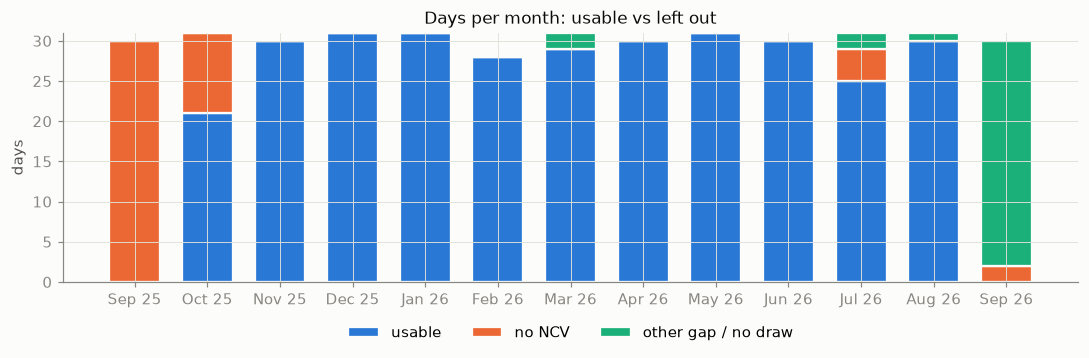

Usable days: 316 of 395 | in the baseline period (Sep-25 to Jul-26): 286, from 2025-10-11


In [2]:
cov = pd.DataFrame({'usable': d.usable, 'no NCV': ~d.ncv_ok, 'other gap / no draw': d.ncv_ok & ~d.usable})
mcov = cov.groupby(d.index.to_period('M')).sum()
fig, ax = plt.subplots(figsize=(10, 3.4))
x = np.arange(len(mcov)); bottom = np.zeros(len(mcov))
for col, colr in [('usable', BLUE), ('no NCV', ORANGE), ('other gap / no draw', AQUA)]:
    ax.bar(x, mcov[col], bottom=bottom, color=colr, label=col, width=0.7, edgecolor=SURF, linewidth=1.5); bottom += mcov[col].values
ax.set_xticks(x); ax.set_xticklabels([p.strftime('%b %y') for p in mcov.index]); ax.set_ylabel('days')
ax.set_title('Days per month: usable vs left out'); ax.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, -0.12))
plt.tight_layout(); plt.show()
print('Usable days: %d of %d | in the baseline period (Sep-25 to Jul-26): %d, from %s' % (d.usable.sum(), len(d), base.shape[0], base.index.min().date()))

- **Sep 2025:** the NCV meter read 0 for the whole month, so no day can be used.
- **Sep 2026:** NCV is fine, but the client hasn't sent the draw yet. That month is the validation set.
- Every other month is almost fully usable.

### 1b. NCV: which readings are accepted?
The NCV meter sometimes reports 0, tiny values, or short spikes. Accepted readings must be:
- between **8,500 and 10,500 kcal/SCM**, and
- within **400 kcal/SCM** of the median of the surrounding ~2 hours (otherwise treated as a spike)

**Why not cut at 9,000?** In Aug–Sep 2026 the gas really was leaner: the daily average was about 9,150, and about 7% of all genuine readings are between 8,500 and 9,000. Cutting at 9,000 would delete real gas quality, not errors.

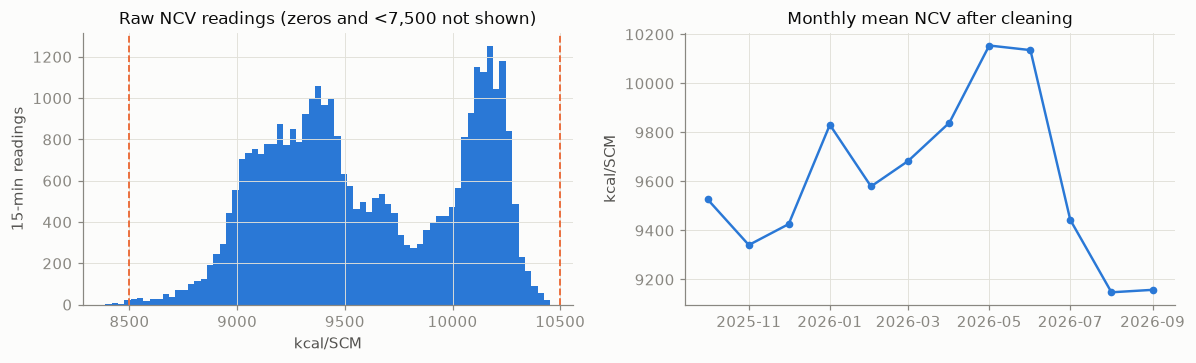

Raw readings: exactly 0 -> 3426 | below 8,500 (non-zero) -> 233 | spikes removed -> 159 | kept -> 33617 (min 8500, max 10454)


In [3]:
raw_ncv = dp.load_ar_raw().groupby('ts').ncv.first()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(raw_ncv[(raw_ncv > 7500) & (raw_ncv < 11000)], bins=70, color=BLUE)
for v in (8500, 10500): ax[0].axvline(v, color=ORANGE, lw=1.2, ls='--')
ax[0].set_title('Raw NCV readings (zeros and <7,500 not shown)'); ax[0].set_xlabel('kcal/SCM'); ax[0].set_ylabel('15-min readings')
mn = q.ncv.groupby(q.index.to_period('M')).mean()
ax[1].plot(mn.index.to_timestamp(), mn.values, color=BLUE, marker='o', ms=4)
ax[1].set_title('Monthly mean NCV after cleaning'); ax[1].set_ylabel('kcal/SCM')
plt.tight_layout(); plt.show()
print('Raw readings: exactly 0 -> %d | below 8,500 (non-zero) -> %d | spikes removed -> %d | kept -> %d (min %.0f, max %.0f)' % (
      (raw_ncv == 0).sum(), ((raw_ncv > 0) & (raw_ncv < 8500)).sum(), int(q.ncv_spike.sum()), q.ncv.notna().sum(), q.ncv.min(), q.ncv.max()))

### 1c. What we do *not* use for learning, and why
| Data | Used? | Reason |
|---|---|---|
| **Optical crown temperature (hourly)** | No (only the daily mean on trustworthy days, 209 of the usable days, for description) | Hand-typed. Day/month swapped and 12-hour clock in 6 months (nb02). It is also held flat by operators (daily sd ≈ 0.5 °C), so it can't explain energy changes |
| **Crown thermocouple TC MC3** | **Not used to train any model.** Only as a check (temperatures on frontier days, §4) | Clean data, but crown temperature responds very weakly to gas changes (≈0.1 °C per 0.1 Gcal/h), and the recommenders don't need it |
| Client workbook values | No (only the 1,576.3 target and band definition) | Our own numbers are recomputed from raw data |

## 2. Do we reproduce the client's baseline?

In [4]:
ours_mean = base.sfc.mean(); ours_w = base.energy_kcal.sum() / base.draw_kg.sum()
pd.DataFrame({'kcal/kg': [ours_mean, ours_w, dp.CLIENT_BASELINE_SFC, ours_mean*0.98, dp.CLIENT_TARGET_SFC]},
             index=['Ours: mean of daily SFC', 'Ours: total energy / total draw', 'Client baseline (stated)',
                    'Ours x 0.98', 'Client target (stated)']).round(1)

,kcal/kg
Ours: mean of daily SFC,1576.6
Ours: total energy / total draw,1573.3
Client baseline (stated),1576.3
Ours x 0.98,1545.0
Client target (stated),1544.8


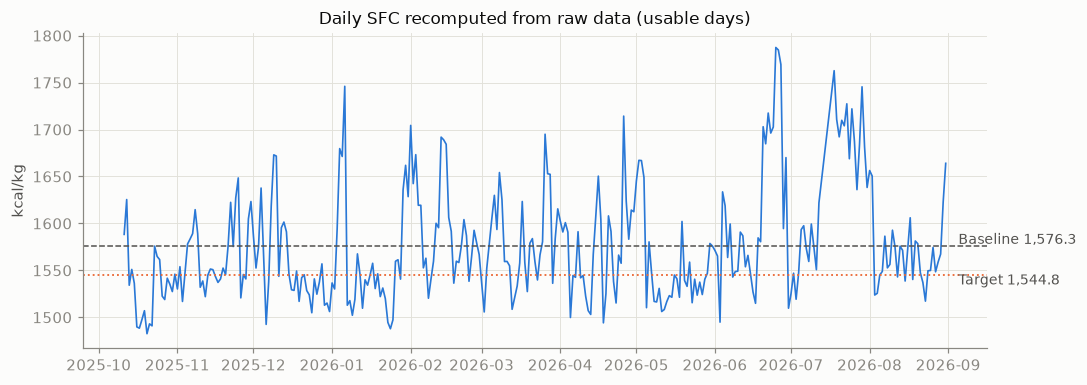

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(u.index, u.sfc, color=BLUE, lw=1.1)
ax.axhline(dp.CLIENT_BASELINE_SFC, color=INK2, lw=1, ls='--'); ax.axhline(dp.CLIENT_TARGET_SFC, color=ORANGE, lw=1.2, ls=':')
xe = u.index.max() + pd.Timedelta(days=5)
label_right(ax, xe, dp.CLIENT_BASELINE_SFC + 6, 'Baseline 1,576.3'); label_right(ax, xe, dp.CLIENT_TARGET_SFC - 6, 'Target 1,544.8')
ax.set_ylabel('kcal/kg'); ax.set_title('Daily SFC recomputed from raw data (usable days)'); plt.tight_layout(); plt.show()

**Insight 1.** Our baseline from raw data is **1,576.6 kcal/kg**, essentially the same as the client's 1,576.3. So the raw data and the client's claim agree, and **1,544.8 is the number to beat**. Daily SFC swings between about 1,460 and 1,790. The next sections explain why.

## 3. Draw: the biggest driver
A furnace loses a lot of heat through its walls, crown, regenerators and flue whether it melts 50 t or 62 t. Only the extra heat to melt each tonne grows with draw. So when draw drops, the same fixed losses are divided over fewer kilograms, and SFC rises.

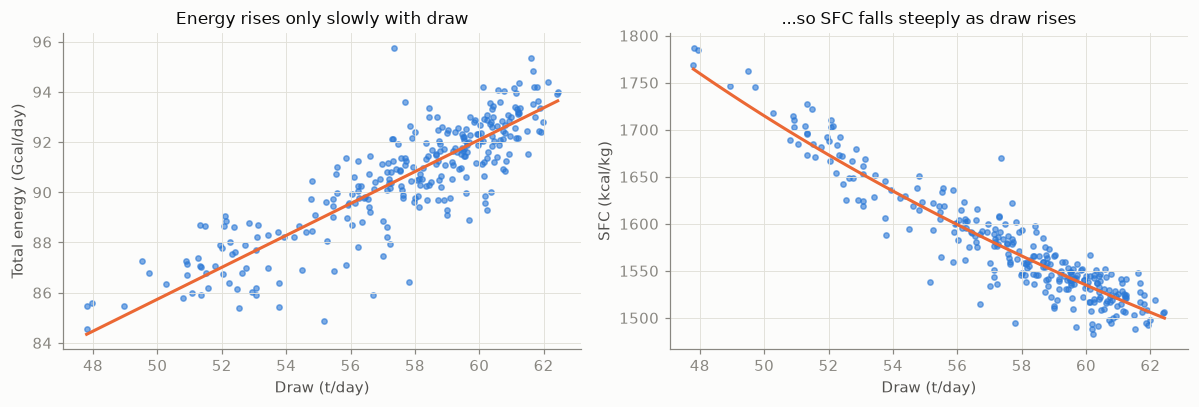

Fixed energy 54.0 Gcal/day (60% of total) + 0.635 Gcal per tonne drawn
+1 t/day draw changes SFC by -1.0%


In [6]:
mA = smf.ols('E_g ~ draw_t + cullet_pct', base).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
mB = smf.ols('E_g ~ draw_t + cullet_pct + age_m', base).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
fixed = mB.params.Intercept + mB.params.cullet_pct*base.cullet_pct.mean() + mB.params.age_m*base.age_m.mean()
xs = np.linspace(base.draw_t.min(), base.draw_t.max(), 50)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].scatter(base.draw_t, base.E_g, s=12, color=BLUE, alpha=0.6)
ax[0].plot(xs, fixed + mB.params.draw_t*xs, color=ORANGE, lw=2)
ax[0].set_xlabel('Draw (t/day)'); ax[0].set_ylabel('Total energy (Gcal/day)'); ax[0].set_title('Energy rises only slowly with draw')
ax[1].scatter(base.draw_t, base.sfc, s=12, color=BLUE, alpha=0.6)
ax[1].plot(xs, (fixed + mB.params.draw_t*xs) / xs * 1000, color=ORANGE, lw=2)
ax[1].set_xlabel('Draw (t/day)'); ax[1].set_ylabel('SFC (kcal/kg)'); ax[1].set_title('...so SFC falls steeply as draw rises')
plt.tight_layout(); plt.show()
var = mB.params.draw_t * base.draw_t.mean()
print('Fixed energy %.1f Gcal/day (%.0f%% of total) + %.3f Gcal per tonne drawn' % (fixed, 100*fixed/(fixed+var), mB.params.draw_t))
s0 = (fixed+var)/base.draw_t.mean(); s1 = (fixed + mB.params.draw_t*(base.draw_t.mean()+1))/(base.draw_t.mean()+1)
print('+1 t/day draw changes SFC by %.1f%%' % (100*(s1/s0-1)))

In [7]:
bins, labels = [45, 50, 55, 60, 65], ['45-50', '50-55', '55-60', '60-65']
base['band'] = pd.cut(base.draw_t, bins, labels=labels, include_lowest=True)
bands = base.groupby('band', observed=True).agg(days=('sfc', 'size'), avg_draw_t=('draw_t', 'mean'), avg_sfc=('sfc', 'mean'))
bands['target_-2%'] = bands.avg_sfc * 0.98
bands['client_avg_sfc'] = [1765.4, 1662.6, 1565.1, 1520.1]     # client SFC Executive sheet (comparison only)
bands.round(1)

,days,avg_draw_t,avg_sfc,target_-2%,client_avg_sfc
band,,,,,
45-50,6,48.6,1765.9,1730.6,1765.4
50-55,52,52.6,1664.0,1630.8,1662.6
55-60,152,57.9,1566.7,1535.4,1565.1
60-65,76,60.9,1521.5,1491.1,1520.1


**Insight 2.**
- About **60% of the energy is fixed**, so each +1 t/day of draw lowers SFC by about **1%**.
- Moving from the 50–55 t band to the 60–65 t band lowers SFC by about 9% with no change in how the furnace is fired.
- That's why the 2% must be judged **per draw band or draw-adjusted**, never on raw monthly averages. Our band averages match the client's within about 1 kcal/kg.

## 4. Furnace ageing: the hidden headwind
Two daily energy models, fitted on the baseline period (HAC standard errors, robust to day-to-day autocorrelation):
- **Model A (for claims):** energy = a + b·draw + c·cullet
- **Model B (for understanding):** Model A + months since Sep 2025

In [8]:
tab = pd.DataFrame({'Model A coef': mA.params, 'A p-value': mA.pvalues, 'Model B coef': mB.params, 'B p-value': mB.pvalues}).round(3)
print('R² A = %.3f | R² B = %.3f | day-to-day noise after Model B: %.1f%% of energy' % (mA.rsquared, mB.rsquared, 100*mB.resid.std()/base.E_g.mean()))
tab

R² A = 0.737 | R² B = 0.771 | day-to-day noise after Model B: 1.2% of energy


,Model A coef,A p-value,Model B coef,B p-value
Intercept,53.547,0.000,53.719,0.000
age_m,NaN,NaN,0.176,0.003
cullet_pct,0.123,0.262,-0.046,0.666
draw_t,0.605,0.000,0.635,0.000


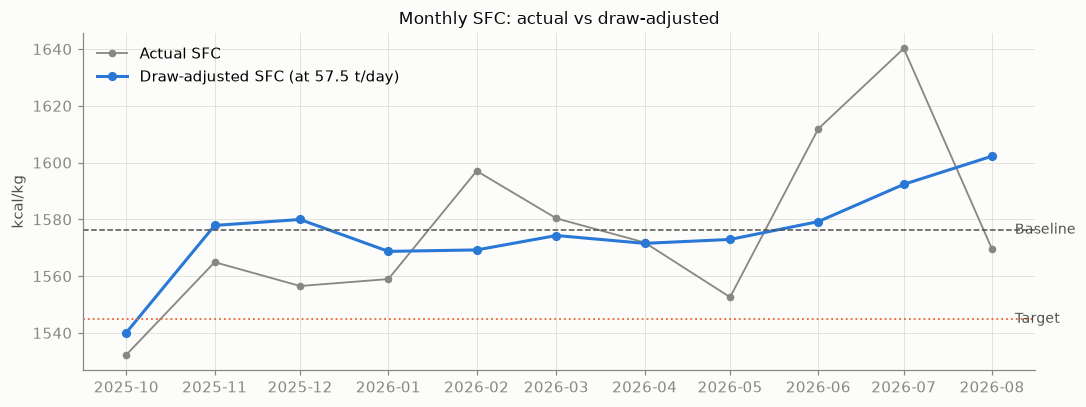

Ageing: +0.19% energy per month at the same draw (p = 0.003)
Jun-Aug 2026, draw-adjusted: 1591 kcal/kg = +0.9% vs baseline -> 2% below baseline needs ~2.9% less energy than today


In [9]:
ref_draw, ref_cul = base.draw_t.mean(), base.cullet_pct.mean()
ref = pd.DataFrame({'draw_t': [ref_draw]*len(u), 'cullet_pct': [ref_cul]*len(u)}, index=u.index)
u['sfc_draw_adj'] = u.sfc * (mA.predict(ref) / ref_draw) / (mA.predict(u) / u.draw_t)
mon = u.groupby(u.index.to_period('M')).agg(draw_t=('draw_t', 'mean'), sfc=('sfc', 'mean'), sfc_draw_adj=('sfc_draw_adj', 'mean'))
fig, ax = plt.subplots(figsize=(10, 3.8)); xm = mon.index.to_timestamp()
ax.plot(xm, mon.sfc, color=MUTED, marker='o', ms=4, lw=1.2, label='Actual SFC')
ax.plot(xm, mon.sfc_draw_adj, color=BLUE, marker='o', ms=5, lw=2, label='Draw-adjusted SFC (at %.1f t/day)' % ref_draw)
ax.axhline(dp.CLIENT_BASELINE_SFC, color=INK2, lw=1, ls='--'); ax.axhline(dp.CLIENT_TARGET_SFC, color=ORANGE, lw=1.2, ls=':')
label_right(ax, xm[-1] + pd.Timedelta(days=8), dp.CLIENT_BASELINE_SFC, 'Baseline'); label_right(ax, xm[-1] + pd.Timedelta(days=8), dp.CLIENT_TARGET_SFC, 'Target')
ax.set_ylabel('kcal/kg'); ax.set_title('Monthly SFC: actual vs draw-adjusted'); ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
recent = u[u.index >= '2026-06-01']
gap_now = 100*(recent.sfc_draw_adj.mean()/dp.CLIENT_BASELINE_SFC - 1)
print('Ageing: +%.2f%% energy per month at the same draw (p = %.3f)' % (100*mB.params.age_m/base.E_g.mean(), mB.pvalues.age_m))
print('Jun-Aug 2026, draw-adjusted: %.0f kcal/kg = %+.1f%% vs baseline -> 2%% below baseline needs ~%.1f%% less energy than today' % (
      recent.sfc_draw_adj.mean(), gap_now, 100*(1 - dp.CLIENT_TARGET_SFC/recent.sfc_draw_adj.mean())))

**Insight 3.**
- With draw removed (blue line), the furnace slowly gets less efficient: about **+0.19% energy per month** (p ≈ 0.004). That's typical refractory and regenerator wear.
- The grey line (actual SFC) jumps around mainly because of draw. The big July spike is mostly low draw, not bad firing.
- **Today's starting point is about 0.9% *above* the baseline** at the same draw. So 2% below the baseline means about 3% below today.
- Cullet (16–20%) has no significant effect in either model, because it only changed about monthly within a narrow range.

## 5. NCV: operators correct gas flow, but late
When NCV rises, each SCM of gas carries more heat, so the gas flow should drop by the same proportion. How much and how fast do operators correct it?

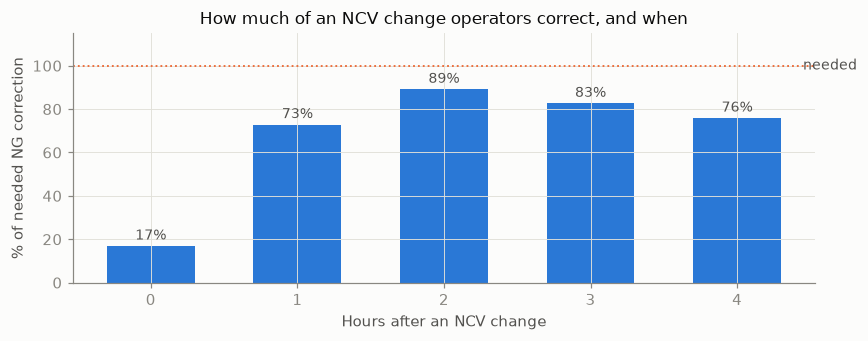

In [10]:
hh = h[h.ncv.notna()].copy(); hh['dn'] = hh.ncv.diff()
ideal = hh.ng_scm.mean() / hh.ncv.mean() * 100
resp = []
for k in range(0, 5):
    hh['dg'] = hh.ng_scm.shift(-k) - hh.ng_scm.shift(1)
    m = smf.ols('dg ~ dn', hh).fit()
    resp.append(dict(hours_after=k, share_of_needed_correction=-m.params.dn*100/ideal))
resp = pd.DataFrame(resp)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(resp.hours_after, resp.share_of_needed_correction*100, color=BLUE, width=0.6)
ax.axhline(100, color=ORANGE, lw=1.2, ls=':'); label_right(ax, 4.45, 100, 'needed')
for x_, y_ in zip(resp.hours_after, resp.share_of_needed_correction*100): ax.text(x_, y_ + 3, '%.0f%%' % y_, ha='center', color=INK2, fontsize=9)
ax.set_xlabel('Hours after an NCV change'); ax.set_ylabel('% of needed NG correction'); ax.set_ylim(0, 115)
ax.set_title('How much of an NCV change operators correct, and when'); plt.tight_layout(); plt.show()

**Insight 4.**
- In the same hour, operators correct only about 17% of an NCV change. After one hour it's about 70%, and after 2 hours about 80%; it never reaches 100%.
- Meanwhile the furnace gets too much or too little heat.
- The gas recommender computes `NG = needed heat ÷ latest NCV` every 15 minutes, which corrects 100% straight away. Its value is that the chosen heat target is *actually delivered*. The saving is measured in notebook 04, not added separately here.

## 6. Barrier boost and the bottom temperature (MB3)
### How it works physically
- **Barrier boost** electrodes sit low in the melter, near the bottom. They pass current through the glass, which heats it from below. That creates a hot "barrier" that controls the convection currents and stops unmelted batch from flowing forward too early.
- The **MB3 thermocouple** is in the melter bottom, so it sees this heat directly.
- **Gas** burns above the glass and heats it from the top. Little of that heat reaches the bottom quickly.

**What we expect:** more barrier boost → MB3 rises, slowly (glass is a large thermal mass), and gas has much less effect on MB3. The four charts below test this.

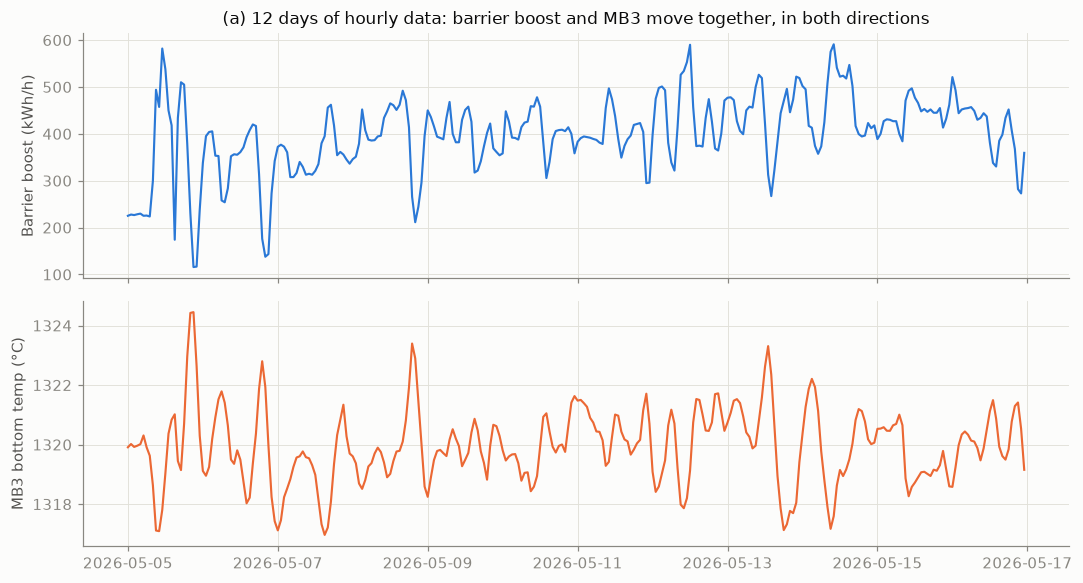

In [11]:
w = h.loc['2026-05-05':'2026-05-16']
fig, ax = plt.subplots(2, 1, figsize=(10, 5.4), sharex=True)
ax[0].plot(w.index, w.bb_kwh, color=BLUE, lw=1.4); ax[0].set_ylabel('Barrier boost (kWh/h)')
ax[1].plot(w.index, w.mb3_temp, color=ORANGE, lw=1.4); ax[1].set_ylabel('MB3 bottom temp (°C)')
ax[0].set_title('(a) 12 days of hourly data: barrier boost and MB3 move together, in both directions')
plt.tight_layout(); plt.show()

**Reading chart (a).** The two signals are clearly linked, but in both directions:
- boost changes heat the bottom a few hours later (the furnace's response)
- operators also cut boost when MB3 is high and raise it when MB3 falls (their feedback; e.g. 5 May: MB3 peaks at 1,324 °C and boost is cut to ~120 kWh/h)

Because of this two-way link, a simple correlation can't measure the furnace's response. Chart (b) separates the two with a distributed-lag model: MB3 changes are regressed on the boost and gas changes of the previous 0–12 hours.

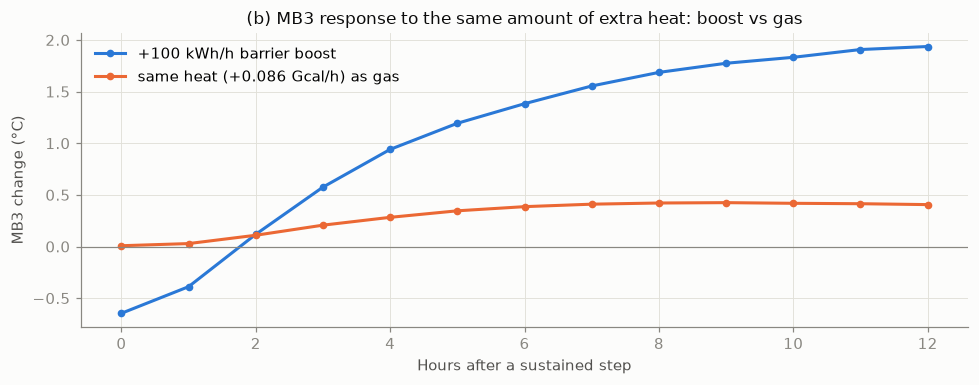

After 12 h: barrier boost +1.94 °C, same heat as gas +0.41 °C per 100 kWh/h-equivalent


In [12]:
lags = 12
x = h[['mb3_temp', 'bb_kwh', 'gas_kcal']].dropna().asfreq('h')
df = pd.DataFrame({'dmb3': x.mb3_temp.diff()})
cols = []
for k in range(lags + 1):
    df[f'dbb{k}'] = x.bb_kwh.diff().shift(k); df[f'dgas{k}'] = (x.gas_kcal/1e6).diff().shift(k); cols += [f'dbb{k}', f'dgas{k}']
dl = smf.ols('dmb3 ~ ' + ' + '.join(cols), df.dropna()).fit()
step_bb = pd.Series([dl.params[f'dbb{k}'] for k in range(lags+1)]).cumsum() * 100          # per +100 kWh/h
step_gas = pd.Series([dl.params[f'dgas{k}'] for k in range(lags+1)]).cumsum() * 0.086       # per +100 kWh/h-equivalent of gas heat
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(step_bb.index, step_bb.values, color=BLUE, marker='o', ms=4, lw=2, label='+100 kWh/h barrier boost')
ax.plot(step_gas.index, step_gas.values, color=ORANGE, marker='o', ms=4, lw=2, label='same heat (+0.086 Gcal/h) as gas')
ax.axhline(0, color=MUTED, lw=0.8); ax.set_xlabel('Hours after a sustained step'); ax.set_ylabel('MB3 change (°C)')
ax.set_title('(b) MB3 response to the same amount of extra heat: boost vs gas'); ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
print('After 12 h: barrier boost +%.2f °C, same heat as gas %+.2f °C per 100 kWh/h-equivalent' % (step_bb.iloc[-1], step_gas.iloc[-1]))

**Reading chart (b).** For the same amount of extra heat, barrier boost raises MB3 by about **1.9 °C** after 6–12 hours. Gas raises it by only about **0.4 °C**, roughly a fifth as much.

The dip in the first 1–2 hours of the boost curve is not physical. Operators tend to raise boost when MB3 is *already falling*, and the regression picks up that feedback. Only the later, rising part is the furnace's response (the controller in nb05 uses only that part).

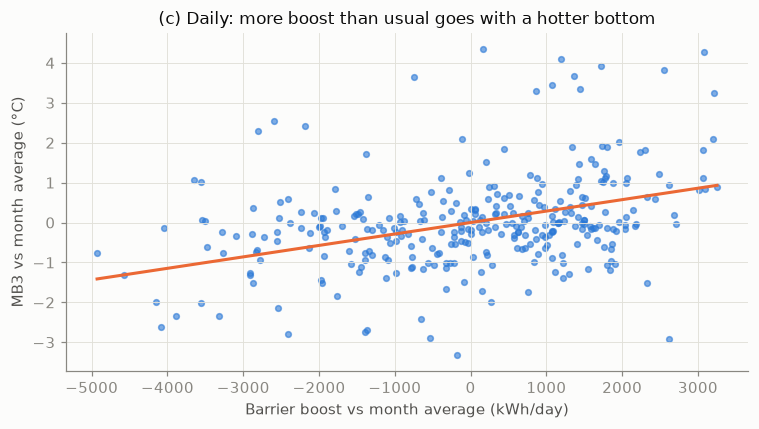

Daily, within the same month: +1,000 kWh/day barrier boost -> MB3 +0.29 °C (p 0.039); +1 Gcal/day gas -> +0.24 °C (p 0.062)


In [13]:
dm = u[['bb_kwh', 'mb3_temp', 'gas_g', 'draw_t', 'mon']].copy()
for c in ['bb_kwh', 'mb3_temp']: dm[c + '_dev'] = dm[c] - dm.groupby('mon')[c].transform('mean')
fit = smf.ols('mb3_temp ~ bb_kwh + gas_g + draw_t + C(mon)', u).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(dm.bb_kwh_dev, dm.mb3_temp_dev, s=14, color=BLUE, alpha=0.6)
xs = np.linspace(dm.bb_kwh_dev.min(), dm.bb_kwh_dev.max(), 20)
ax.plot(xs, fit.params.bb_kwh * xs, color=ORANGE, lw=2)
ax.set_xlabel('Barrier boost vs month average (kWh/day)'); ax.set_ylabel('MB3 vs month average (°C)')
ax.set_title('(c) Daily: more boost than usual goes with a hotter bottom'); plt.tight_layout(); plt.show()
print('Daily, within the same month: +1,000 kWh/day barrier boost -> MB3 %+.2f °C (p %.3f); +1 Gcal/day gas -> %+.2f °C (p %.3f)' % (
      fit.params.bb_kwh*1000, fit.pvalues.bb_kwh, fit.params.gas_g, fit.pvalues.gas_g))

**Reading chart (c).** Comparing days within the same month (so ageing doesn't interfere), days with more barrier boost than usual have a warmer bottom. The daily relationship is weaker than the hourly step response, because operators also adjust boost *in response to* MB3, which hides part of the effect in daily averages.

### Does barrier boost save energy? (correction of an earlier finding)
Boost puts heat directly into the glass, so it should replace gas. But by how much? If 1 Gcal of boost replaced more than 1 Gcal of gas, more boost would lower SFC.

The coefficient is estimated three ways; only the ones that control for ageing are trustworthy, because boost fell over the same months the furnace aged.

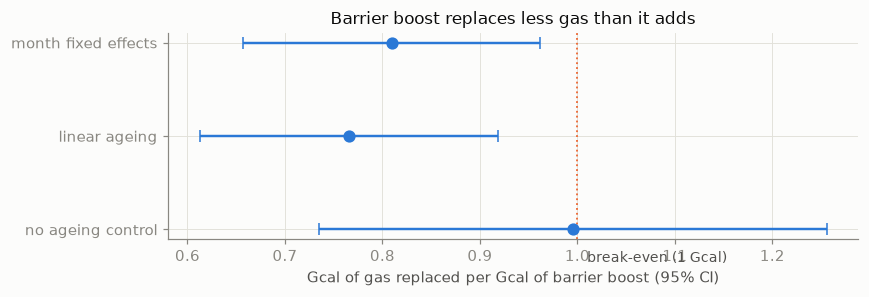

,model,gas_replaced,lo,hi
0,no ageing control,1.00,0.74,1.26
1,linear ageing,0.77,0.61,0.92
2,month fixed effects,0.81,0.66,0.96


In [14]:
res = []
for name, f in [('no ageing control', 'gas_g ~ draw_t + bb_g + mb_g'), ('linear ageing', 'gas_g ~ draw_t + bb_g + mb_g + age_m'),
                ('month fixed effects', 'gas_g ~ draw_t + bb_g + mb_g + C(mon)')]:
    m = smf.ols(f, u).fit(cov_type='HAC', cov_kwds={'maxlags': 7}); lo, hi = m.conf_int().loc['bb_g']
    res.append(dict(model=name, gas_replaced=-m.params.bb_g, lo=-hi, hi=-lo))
res = pd.DataFrame(res)
fig, ax = plt.subplots(figsize=(8, 2.8))
yy = np.arange(len(res))
ax.errorbar(res.gas_replaced, yy, xerr=[res.gas_replaced - res.lo, res.hi - res.gas_replaced], fmt='o', color=BLUE, ecolor=BLUE, capsize=4, ms=7)
ax.axvline(1.0, color=ORANGE, lw=1.2, ls=':'); ax.text(1.01, -0.35, 'break-even (1 Gcal)', color=INK2, fontsize=9)
ax.set_yticks(yy); ax.set_yticklabels(res.model); ax.set_xlabel('Gcal of gas replaced per Gcal of barrier boost (95% CI)')
ax.set_title('Barrier boost replaces less gas than it adds'); plt.tight_layout(); plt.show()
res.round(2)

**Insight 5: barrier boost.**
1. **Barrier boost is the handle for the bottom temperature.** +100 kWh/h raises MB3 by about 1.9 °C within 6–12 hours. The same heat as gas moves MB3 only about 0.4 °C. This confirms the plant's design for Model 2 (boost recommended from MB3).
2. **Boost is not an energy saver.** Once ageing is controlled, 1 Gcal of boost replaces only about **0.8 Gcal of gas** (the confidence interval stays below 1). Total energy, and SFC, go up when boost goes up.
3. So the right use of boost is **the minimum needed to hold MB3 at its target**.
   - In Jun–Aug 2026, MB3 ran about 1.5 °C above its historical median.
   - That means boost was higher than needed.
   - This is lever 3 (sized in nb05).

## 7. Air per Mcal of gas heat

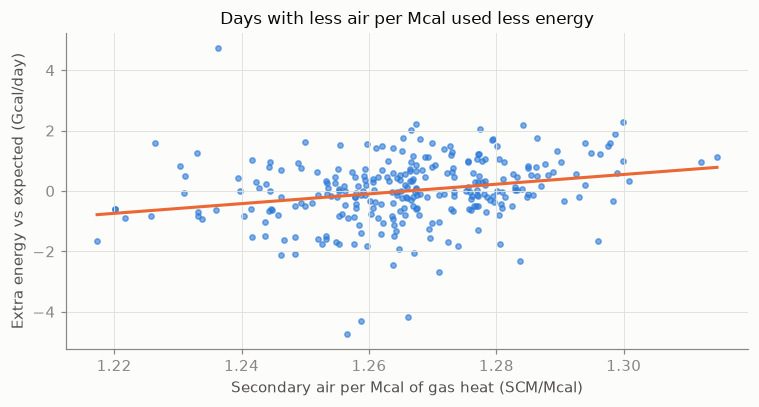

+0.01 SCM/Mcal air -> +0.16 Gcal/day (p 0.002). Median 1.267 -> historical P25 1.258 saves about 0.16% energy


In [15]:
z = base.copy(); z['resid'] = mB.resid
ma = smf.ols('resid ~ air_per_mcal', z).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.scatter(z.air_per_mcal, z.resid, s=12, color=BLUE, alpha=0.6)
xs = np.linspace(z.air_per_mcal.min(), z.air_per_mcal.max(), 20); ax.plot(xs, ma.params.Intercept + ma.params.air_per_mcal*xs, color=ORANGE, lw=2)
ax.set_xlabel('Secondary air per Mcal of gas heat (SCM/Mcal)'); ax.set_ylabel('Extra energy vs expected (Gcal/day)')
ax.set_title('Days with less air per Mcal used less energy'); plt.tight_layout(); plt.show()
air_target = u.air_per_mcal.quantile(0.25)
air_saving = ma.params.air_per_mcal * (u.air_per_mcal.median() - air_target) / base.E_g.mean() * 100
print('+0.01 SCM/Mcal air -> %+.2f Gcal/day (p %.3f). Median %.3f -> historical P25 %.3f saves about %.2f%% energy' % (
      ma.params.air_per_mcal/100, ma.pvalues.air_per_mcal, u.air_per_mcal.median(), air_target, air_saving))

**Insight 6.**
- Air already follows NCV, at about 1.27 SCM of air per Mcal of gas.
- Within the historical range, days with less air per Mcal used significantly less energy: extra air is heated and leaves through the flue.
- There is no O₂ analyser, so the recommender never goes below what the furnace has already run at. The target is the historical 25th percentile, worth about **0.15%**.

## 8. Quality guard-rail: seeds, and which days are most efficient

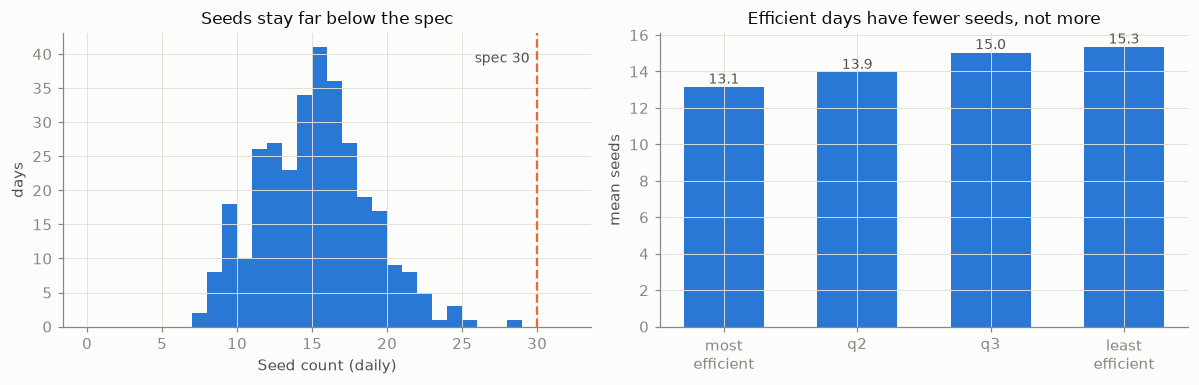

Seeds: mean 14.7, P95 21, max 28, days above spec 30: 0 of 316


In [16]:
z['grp'] = pd.qcut(z.resid, 4, labels=['most efficient 25%', 'q2', 'q3', 'least efficient 25%'])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(u.seed_count, bins=range(0, 33), color=BLUE); ax[0].axvline(30, color=ORANGE, lw=1.5, ls='--')
ax[0].text(29.5, ax[0].get_ylim()[1]*0.9, 'spec 30', color=INK2, ha='right', fontsize=9)
ax[0].set_xlabel('Seed count (daily)'); ax[0].set_ylabel('days'); ax[0].set_title('Seeds stay far below the spec')
sm = z.groupby('grp', observed=True).seed_count.mean()
ax[1].bar(range(4), sm.values, color=BLUE, width=0.6); ax[1].set_xticks(range(4)); ax[1].set_xticklabels(['most\nefficient', 'q2', 'q3', 'least\nefficient'])
for i, v in enumerate(sm.values): ax[1].text(i, v + 0.2, '%.1f' % v, ha='center', color=INK2, fontsize=9)
ax[1].set_ylabel('mean seeds'); ax[1].set_title('Efficient days have fewer seeds, not more')
plt.tight_layout(); plt.show()
print('Seeds: mean %.1f, P95 %.0f, max %d, days above spec 30: %d of %d' % (u.seed_count.mean(), u.seed_count.quantile(.95), u.seed_count.max(), (u.seed_count > 30).sum(), len(u)))

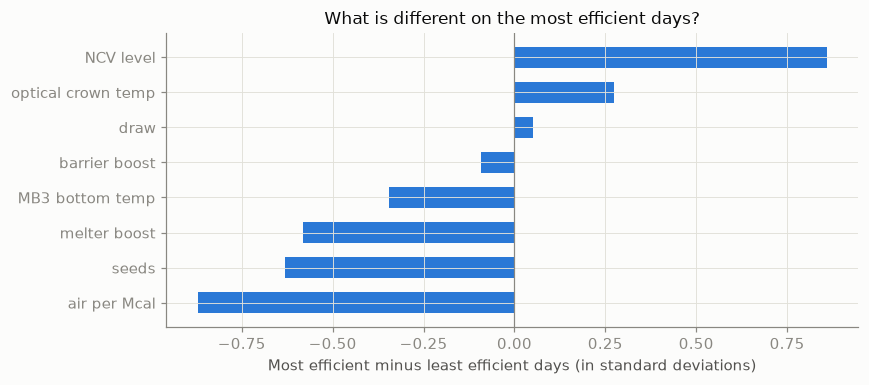

grp,most efficient 25%,q2,q3,least efficient 25%
air per Mcal,1.26,1.27,1.27,1.27
melter boost,7745.04,7568.82,7660.67,8222.29
barrier boost,8630.62,8695.58,8668.24,8802.30
MB3 bottom temp,1319.91,1320.48,1320.56,1320.40
NCV level,9824.52,9803.74,9699.47,9496.37
seeds,13.14,13.94,15.03,15.33
optical crown temp,1574.70,1574.64,1574.64,1574.58
draw,57.69,57.60,57.35,57.52


In [17]:
cols = {'air_per_mcal': 'air per Mcal', 'mb_kwh': 'melter boost', 'bb_kwh': 'barrier boost', 'mb3_temp': 'MB3 bottom temp',
        'ncv': 'NCV level', 'seed_count': 'seeds', 'opt_temp': 'optical crown temp', 'draw_t': 'draw'}
bw = z.groupby('grp', observed=True)[list(cols)].mean()
diff = (bw.loc['most efficient 25%'] - bw.loc['least efficient 25%']) / z[list(cols)].std()
diff = diff.rename(cols).sort_values()
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(diff.index, diff.values, color=BLUE, height=0.6); ax.axvline(0, color=MUTED, lw=0.8)
ax.set_xlabel('Most efficient minus least efficient days (in standard deviations)')
ax.set_title('What is different on the most efficient days?'); plt.tight_layout(); plt.show()
(bw.T.rename(index=cols)).round(2)

**Insight 7.**
- Seeds never exceeded the spec of 30 on usable days (P95 = 21). The most efficient days have **fewer** seeds, so saving energy within the historical range does not hurt quality.
- Compared with the least efficient days, the most efficient days had:
  - **less air per Mcal**
  - **less melter boost**
  - a **slightly cooler bottom (MB3)**
  - **higher NCV**
  - **the same draw and almost the same optical temperature** (+0.1 °C)

  Each of these differences points to a lever in §9.

## 9. Optical crown temperature: why it can't give historical insight

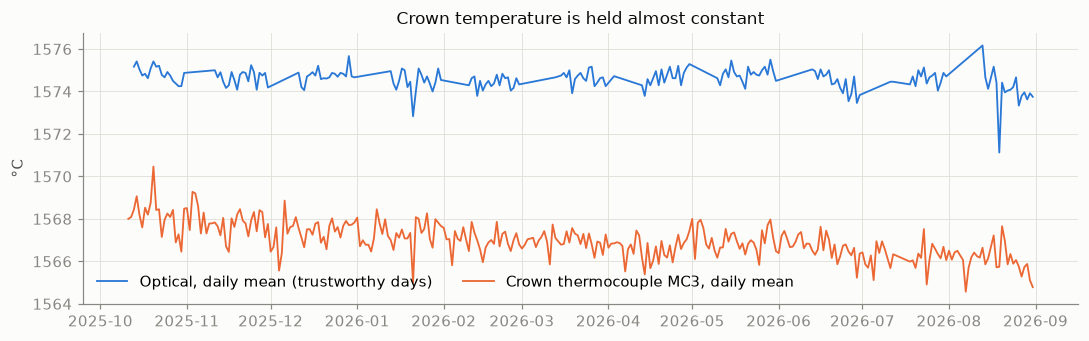

Optical daily sd 0.50 °C on 209 trustworthy days | thermocouple daily sd 0.83 °C


In [18]:
ok = u[u.opt_day_ok]
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(ok.index, ok.opt_temp, color=BLUE, lw=1.2, label='Optical, daily mean (trustworthy days)')
ax.plot(u.index, u.crown_tc, color=ORANGE, lw=1.2, label='Crown thermocouple MC3, daily mean')
ax.set_ylabel('°C'); ax.legend(loc='lower left', ncol=2); ax.set_title('Crown temperature is held almost constant')
plt.tight_layout(); plt.show()
print('Optical daily sd %.2f °C on %d trustworthy days | thermocouple daily sd %.2f °C' % (ok.opt_temp.std(), len(ok), u.crown_tc.std()))

**Insight 8.**
- Operators hold the crown at about 1,574.5 °C (optical). It barely moves, so history can't tell us what a lower crown setpoint would save. That has to come from a small **step trial**: −1 °C at a time, with daily seed checks.
- The thermocouple confirms the crown is steady. It isn't used to train any model.

## 10. Savings bridge: how far do the proven levers get us?

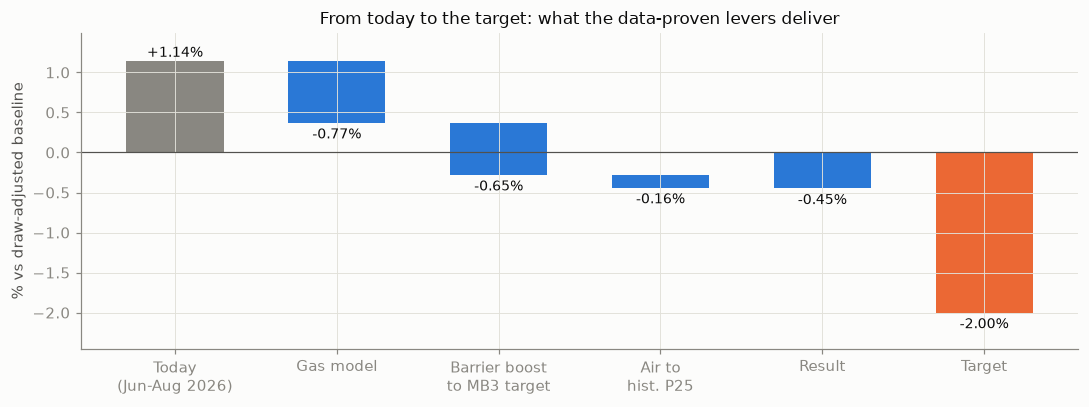

,step,% vs draw-adjusted baseline
0,"Jun-Aug 2026 actual, draw-adjusted vs baseline",1.14
1,"Gas model (frontier + exact NCV compensation),...",-0.77
2,Barrier boost to hold MB3 at historical median...,-0.65
3,"Air per Mcal to historical P25 (estimate), nb03",-0.16
4,= Result with all data-proven levers,-0.45
5,Target,-2.00
6,Remaining gap (needs trial levers / draw),-1.55


In [19]:
p = '../data/processed/path_to_2pct.csv'
import os
if os.path.exists(p):
    br = pd.read_csv(p)
    steps = br.iloc[[1, 2, 3]]
    start = br.iloc[0, 1]; end = br.iloc[4, 1]; target = br.iloc[5, 1]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    labels_ = ['Today\n(Jun-Aug 2026)', 'Gas model', 'Barrier boost\nto MB3 target', 'Air to\nhist. P25', 'Result', 'Target']
    vals = [start] + list(steps.iloc[:, 1]) + [end, target]
    cum = start
    ax.bar(0, start, color=MUTED, width=0.6)
    for i, v in enumerate(steps.iloc[:, 1], start=1):
        ax.bar(i, v, bottom=cum, color=BLUE, width=0.6); cum += v
    ax.bar(4, end, color=BLUE, width=0.6); ax.bar(5, target, color=ORANGE, width=0.6)
    cum = start
    for i, v in enumerate(vals):
        if i in (1, 2, 3):
            cum += v; y = cum - 0.15
        else:
            y = v + 0.1 if v >= 0 else v - 0.15
        ax.text(i, y, '%+.2f%%' % v, ha='center', va='center', color=INK, fontsize=9)
    ax.set_ylim(min(target, end) - 0.45, start + 0.35)
    ax.axhline(0, color=INK2, lw=0.8); ax.set_xticks(range(6)); ax.set_xticklabels(labels_)
    ax.set_ylabel('% vs draw-adjusted baseline'); ax.set_title('From today to the target: what the data-proven levers deliver')
    plt.tight_layout(); plt.show()
    display(br)
else:
    print('Run notebook 05 first to create', p)

## 11. Conclusions
**What the data shows**
1. **The baseline is confirmed.** Recomputed from raw data, it is 1,576.6 kcal/kg (client: 1,576.3). The target is 1,544.8, or −2% per draw band.
2. **Draw explains most of the SFC swings.** About 60% of the energy is fixed, so +1 t/day draw ≈ −1% SFC. Judge results per band or draw-adjusted.
3. **The furnace is ageing:** +0.19% energy per month. Today it runs about 1% above the baseline at the same draw, so reaching −2% means about −3% versus today.
4. **NCV is corrected late:** about 70% after one hour. The gas recommender corrects it fully every 15 minutes.
5. **Barrier boost controls the bottom temperature** (+1.9 °C per +100 kWh/h) **but doesn't save energy** (it replaces only ~0.8 Gcal of gas per Gcal). Use the minimum boost that holds MB3. MB3 ran 1.5 °C above its historical median in Jun–Aug 2026.
6. **Less air per Mcal saves energy** within the proven range (~0.15%). Going further needs an O₂ analyser.
7. **Quality is not at risk:** seeds are far below the spec, and the efficient days have fewer seeds.
8. **Optical can't give historical insight.** It is held flat and its log has date errors. It stays a live input and guard-rail.

**What it means for the 2% target**

| | % vs draw-adjusted baseline |
|---|---|
| Today (Jun–Aug 2026) | about +1.1% |
| Gas recommender (nb04) + barrier-boost controller (nb05) + air trim | about −0.45% (see the waterfall above) |
| **Remaining gap to −2%** | **about 1.5 points** |

**How to close the gap** (each needs a plant trial with daily seed checks):
- lower the optical crown setpoint by 1–2 °C (seed headroom: P95 = 21 against a spec of 30)
- move the MB3 target toward the historical 25th percentile (still inside past operation)
- keep draw high and avoid line stops (+1 t/day ≈ −1% SFC)